In [185]:
import datetime
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [192]:
base_path = Path("D:/clickbait-place/data/pid-map")
pid_signal = np.fromfile(f"{base_path}/pid_signal.bin", dtype="float")
button_ts = pd.read_csv(f"{base_path}/button_press.csv", header=None, names=["timestamp"])
odor_l_ts = pd.read_csv(f"{base_path}/left_odor_on.csv", header=None, names=["timestamp"])
odor_r_ts = pd.read_csv(f"{base_path}/right_odor_on.csv", header=None, names=["timestamp"])
seq_end = pd.read_csv(f"{base_path}/sequence_end.csv", header=None, names=["timestamp"])
video_ts = pd.read_csv(f"{base_path}/pid_video_ts.csv", header=None, names=["timestamp"])
zero_ts = pd.read_csv(f"{base_path}/zero_ts.csv", header=None, names=["timestamp"])

In [193]:
# Convert datetime to milliseconds
button_ts["timestamp"] = pd.to_datetime(button_ts["timestamp"])
button_ts["timestamp_ms"] = button_ts["timestamp"].astype(np.int64) // 10**6
odor_l_ts["timestamp"] = pd.to_datetime(odor_l_ts["timestamp"])
odor_l_ts["timestamp_ms"] = odor_l_ts["timestamp"].astype(np.int64) // 10**6
odor_r_ts["timestamp"] = pd.to_datetime(odor_r_ts["timestamp"])
odor_r_ts["timestamp_ms"] = odor_r_ts["timestamp"].astype(np.int64) // 10**6
seq_end["timestamp"] = pd.to_datetime(seq_end["timestamp"])
seq_end["timestamp_ms"] = seq_end["timestamp"].astype(np.int64) // 10**6
video_ts["timestamp"] = pd.to_datetime(video_ts["timestamp"])
video_ts["timestamp_ms"] = video_ts["timestamp"].astype(np.int64) // 10**6
zero_ts["timestamp"] = pd.to_datetime(zero_ts["timestamp"])
zero_ts["timestamp_ms"] = zero_ts["timestamp"].astype(np.int64) // 10**6

# Subtract the first timestamp to get relative times
button_ts["relative_time_ms"] = button_ts["timestamp_ms"] - zero_ts["timestamp_ms"].iloc[0]
seq_end["relative_time_ms"] = seq_end["timestamp_ms"] - zero_ts["timestamp_ms"].iloc[0]
odor_l_ts["relative_time_ms"] = odor_l_ts["timestamp_ms"] - zero_ts["timestamp_ms"].iloc[0]
odor_r_ts["relative_time_ms"] = odor_r_ts["timestamp_ms"] - zero_ts["timestamp_ms"].iloc[0]
video_ts["relative_time_ms"] = video_ts["timestamp_ms"] - zero_ts["timestamp_ms"].iloc[0]

In [197]:
len(button_ts)

144

In [190]:
seq_end

,timestamp,timestamp_ms,relative_time_ms
0,2026-05-13 21:01:16.953433600,1778706076953,29493
1,2026-05-13 21:01:51.780620800,1778706111780,64320
2,2026-05-13 21:02:25.153088000,1778706145153,97693
3,2026-05-13 21:03:00.901260800,1778706180901,133441
4,2026-05-13 21:03:39.247961600,1778706219247,171787
...,...,...,...
139,2026-05-13 22:24:18.708902400,1778711058708,5011248
140,2026-05-13 22:24:57.616179200,1778711097616,5050156
141,2026-05-13 22:25:38.161523200,1778711138161,5090701
142,2026-05-13 22:26:14.993280000,1778711174993,5127533


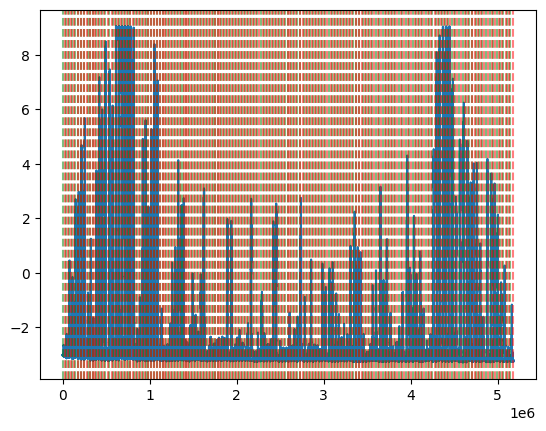

In [191]:
plt.plot(pid_signal)
# Add vertical lines for button presses
for ts in button_ts["relative_time_ms"]:
    plt.axvline(x=ts, color="green", linestyle="--", alpha=0.5)
# Add vertical lines for sequence ends
for ts in seq_end["relative_time_ms"]:
    plt.axvline(x=ts, color="red", linestyle="--", alpha=0.5)
# Add vertical lines for left odor on
# for ts in odor_l_ts["relative_time_ms"]:
#     plt.axvline(x=ts, color="black", linestyle="--", alpha=0.25)
# # Add vertical lines for right odor on
# for ts in odor_r_ts["relative_time_ms"]:
#     plt.axvline(x=ts, color="black", linestyle="--", alpha=0.25)

In [ ]:
# Get 